# Plot Segmentation Exmaple

## Load Libraries 

In [1]:
import intake
import healpy as hp

import numpy as np
import xarray as xr

import pandas as pd
import scipy.ndimage
import seaborn as sns


import tobac
from tobac.utils import get_statistics_from_mask


import matplotlib.pyplot as plt
import cartopy.feature as cf
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle, Polygon

## Define functions

In [2]:
def get_nn_lon_lat_index(nside, lons, lats):
    lons2, lats2 = np.meshgrid(lons, lats)
    
    lon = xr.DataArray(lons, dims=("lon",), name="lon", attrs=dict(units="degrees", standard_name="longitude"))
    lat = xr.DataArray(lats, dims=("lat",), name="lat", attrs=dict(units="degrees", standard_name="latitude"))
    
    pix = xr.DataArray(
        hp.ang2pix(dataset.crs.healpix_nside, *np.meshgrid(lon, lat), nest=True, lonlat=True),
        coords=(lat, lon),
    )
    return pix
    

def relabel_array(input_array):
    """
    Relabels a NumPy array such that the most frequently occurring non-zero labels 
    are reassigned to sequential integers starting from 1.

    Parameters:
    input_array (np.ndarray): The input NumPy array containing integers and zeros.

    Returns:
    np.ndarray: A new array with the labels relabeled.
    """
    # Step 1: Count occurrences of non-zero values
    unique, counts = np.unique(input_array[input_array != 0], return_counts=True)
    counts_dict = dict(zip(unique, counts))

    # Step 2: Sort the labels by frequency
    sorted_labels = sorted(counts_dict, key=counts_dict.get, reverse=True)

    # Step 3: Create a mapping from old labels to new labels
    label_mapping = {label: index + 1 for index, label in enumerate(sorted_labels)}

    # Step 4: Create a new array and relabel using the mapping
    relabelled_array = np.copy(input_array)
    for old_label, new_label in label_mapping.items():
        relabelled_array[input_array == old_label] = new_label

    return relabelled_array



## Open Data 

In [3]:
itime = 0
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
exp_id = "ngc4008"
zoom = 9
dataset = cat.ICON[exp_id](zoom=zoom, time = 'PT3H', chunks = 'auto').to_dask( )
display(dataset)

/work/bb1376/user/leonie/conda/envs/MA_numpy23/lib/python3.11/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 849TB
Dimensions:                              (time: 87664, depth_half: 73,
                                          cell: 3145728, level_full: 90,
                                          soil_depth_water_level: 5,
                                          depth_full: 72,
                                          soil_depth_energy_level: 5,
                                          level_half: 91, crs: 1)
Coordinates:
  * time                                 (time) datetime64[ns] 701kB 2020-01-...
  * depth_half                           (depth_half) float32 292B 0.0 ... 5....
    zg                                   (level_full, cell) float32 1GB dask.array<chunksize=(90, 360448), meta=np.ndarray>
  * level_full                           (level_full) int32 360B 1 2 3 ... 89 90
  * soil_depth_water_level               (soil_depth_water_level) float32 20B ...
  * depth_full                           (depth_full) float32 288B 1.0 ... 5....
  * soil_depth_energy_level              (soil_depth_energy_level) float32 20B ...
  * crs                                  (crs) float32 4B nan
Dimensions without coordinates: cell, level_half
Data variables: (12/85)
    A_tracer_v_to                        (time, depth_half, cell) float32 81TB dask.array<chunksize=(32, 30, 32768), meta=np.ndarray>
    Qbot                                 (time, cell) float32 1TB dask.array<chunksize=(496, 32768), meta=np.ndarray>
    Qtop                                 (time, cell) float32 1TB dask.array<chunksize=(496, 32768), meta=np.ndarray>
    Wind_Speed_10m                       (time, cell) float32 1TB dask.array<chunksize=(496, 32768), meta=np.ndarray>
    atmos_fluxes_FrshFlux_Evaporation    (time, cell) float32 1TB dask.array<chunksize=(496, 32768), meta=np.ndarray>
    atmos_fluxes_FrshFlux_Precipitation  (time, cell) float32 1TB dask.array<chunksize=(496, 32768), meta=np.ndarray>
    ...                                   ...
    v_vint                               (time, cell) float32 1TB dask.array<chunksize=(496, 32768), meta=np.ndarray>
    va                                   (time, level_full, cell) float32 99TB dask.array<chunksize=(32, 30, 32768), meta=np.ndarray>
    vas                                  (time, cell) float32 1TB dask.array<chunksize=(496, 32768), meta=np.ndarray>
    w                                    (time, depth_half, cell) float32 81TB dask.array<chunksize=(32, 30, 32768), meta=np.ndarray>
    zghalf                               (level_half, cell) float32 1GB dask.array<chunksize=(91, 360448), meta=np.ndarray>
    zos                                  (time, cell) float32 1TB dask.array<chunksize=(496, 32768), meta=np.ndarray>

In [4]:
dataset = dataset.sel(time = slice('2021-08', '2021-09'))

## Prepare Data 

In [5]:
dataset['rain_tot_rate'] = 3600 * 24 * ( dataset['pr'] )  # unit convetion to mm day-1

dataset['rain_tot_rate'].attrs['units'] = 'mm day-1'

dataset['rain_tot_rate'].attrs['long_name'] = 'rain rate'


In [6]:
dataset['fwp'] = dataset['clivi'] + dataset['qsvi']

dataset['fwp'].attrs['units'] = 'kg m-2'

dataset['fwp'].attrs['long_name'] = 'frozen water path'


## Resample Data

In [7]:
idx = get_nn_lon_lat_index(
    2**zoom, np.arange(-180, 180, 0.1), np.arange(-30, 30, 0.1)
)

In [8]:
vlist = ['cllvi', 'fwp', 'prw', 'rain_tot_rate']

In [9]:
d = dataset[vlist]
d_lon_lat = d.isel(time = [itime,itime+1], cell=idx)

In [10]:
ts = pd.to_datetime(dataset.time)

time_str = ts.to_pydatetime()[itime].strftime('%Y-%m-%d_%H%M')

## Overview Plots 

### Tropical Belt

/work/bb1376/user/leonie/conda/envs/MA_numpy23/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/bb1376/user/leonie/conda/envs/MA_numpy23/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/bb1376/user/leonie/conda/envs/MA_numpy23/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/bb1376/user/leonie/conda/envs/MA_numpy23/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it

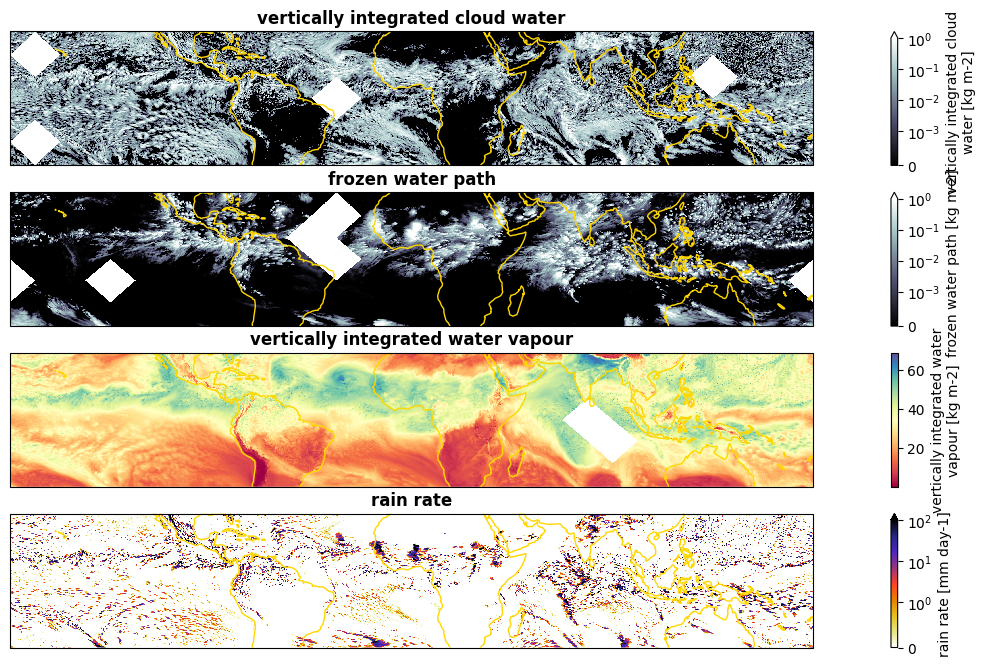

In [11]:
cmaps = [ 'bone', 'bone','Spectral','CMRmap_r' ]

LNc = plt.matplotlib.colors.SymLogNorm(linthresh = 1e-3, vmax= 1)
LNr = plt.matplotlib.colors.SymLogNorm(linthresh = 1, vmax= 100)
NN = plt.matplotlib.colors.Normalize()

norms = [LNc, LNc, NN, LNr]

target_map = ccrs.PlateCarree()
fig, axs = plt.subplots(ncols=1, nrows = 4, subplot_kw={'projection': target_map}, figsize = (20,8))
plt.subplots_adjust( wspace = 0.)
axs = axs.flatten()

for i, vname in enumerate( vlist ):
    a = axs[i]
    plt.sca(a)
    a.add_feature(cf.COASTLINE, color = 'gold')

    v = d_lon_lat[vname].isel(time=0)
    v.plot(    
        transform=ccrs.PlateCarree(),  # the data's projection
        subplot_kws={"projection": target_map},
        norm = norms[i],
        cmap=cmaps[i]
    )
    a.set_title( v.long_name, fontweight = 'bold' )
    
    

## Using tobac Feature Detection for Segmentation 

### Lon/Lat 

In [12]:
dlon = d_lon_lat.lon.diff('lon').mean().data
dlat = d_lon_lat.lat.diff('lat').mean().data

lat0 = d_lon_lat.lat.mean('lat').mean().data

### Equivalent Grid Size 

In [13]:
R_earth = 6371e3

dlambda = np.deg2rad( dlon )
dphi = np.deg2rad( dlat )
phi0 = np.deg2rad( lat0 )

dA = R_earth**2 * np.cos( phi0 ) * dlambda * dphi

dX = np.sqrt( dA )
print(dX)

11119.490547461091


### Conversion to Iris.Cube 

In [14]:
RR = d_lon_lat['rain_tot_rate'].to_iris()

In [15]:
RR

<iris 'Cube' of rain rate / (mm day-1) (time: 2; latitude: 600; longitude: 3600)>

In [16]:
dxy = dX

### Segmentation 

In [17]:
thresholds = [100,]#9,10] #np.arange(8,11)  )
print(thresholds)

# Dictionary containing keyword arguments for segmentation step:
parameters_segmentation={}
parameters_segmentation['method']='watershed'
parameters_segmentation['threshold']=10  # mm/h mixing ratio


[100]


In [18]:
features = tobac.feature_detection_multithreshold(
    RR, dxy, thresholds, target="maximum", position_threshold="weighted_diff"
)

In [19]:
Mask_Precip,Features_Precip=tobac.segmentation_2D(features,RR,dxy,**parameters_segmentation)


In [20]:
statistics = {}
statistics['mean_precip'] = np.mean
statistics['total_precip'] = np.sum
statistics['max_precip'] = np.max
statistics['percentiles'] = (np.percentile, {'q': [95,99]})

In [21]:
features_with_stats = get_statistics_from_mask(Features_Precip, Mask_Precip, RR, statistic=statistics)

In [22]:
area = tobac.calculate_area(features_with_stats, Mask_Precip)

/work/bb1376/user/leonie/conda/envs/MA_numpy23/lib/python3.11/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning: Using DEFAULT_SPHERICAL_EARTH_RADIUS.
  warnings.warn(


In [23]:
final_features = pd.concat([features_with_stats, area])

In [24]:
v

<xarray.DataArray 'rain_tot_rate' (lat: 600, lon: 3600)> Size: 9MB
dask.array<getitem, shape=(600, 3600), dtype=float32, chunksize=(600, 3600), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 5kB -30.0 -29.9 -29.8 -29.7 ... 29.6 29.7 29.8 29.9
  * lon      (lon) float64 29kB -180.0 -179.9 -179.8 ... 179.7 179.8 179.9
    time     datetime64[ns] 8B 2021-08-01
Attributes:
    cell_methods:  time: mean cell: mean
    component:     atmo
    grid_mapping:  crs
    long_name:     rain rate
    units:         mm day-1
    vgrid:         surface

## Plotting

In [25]:
label = xr.DataArray.from_iris(Mask_Precip)

/work/bb1376/user/leonie/conda/envs/MA_numpy23/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


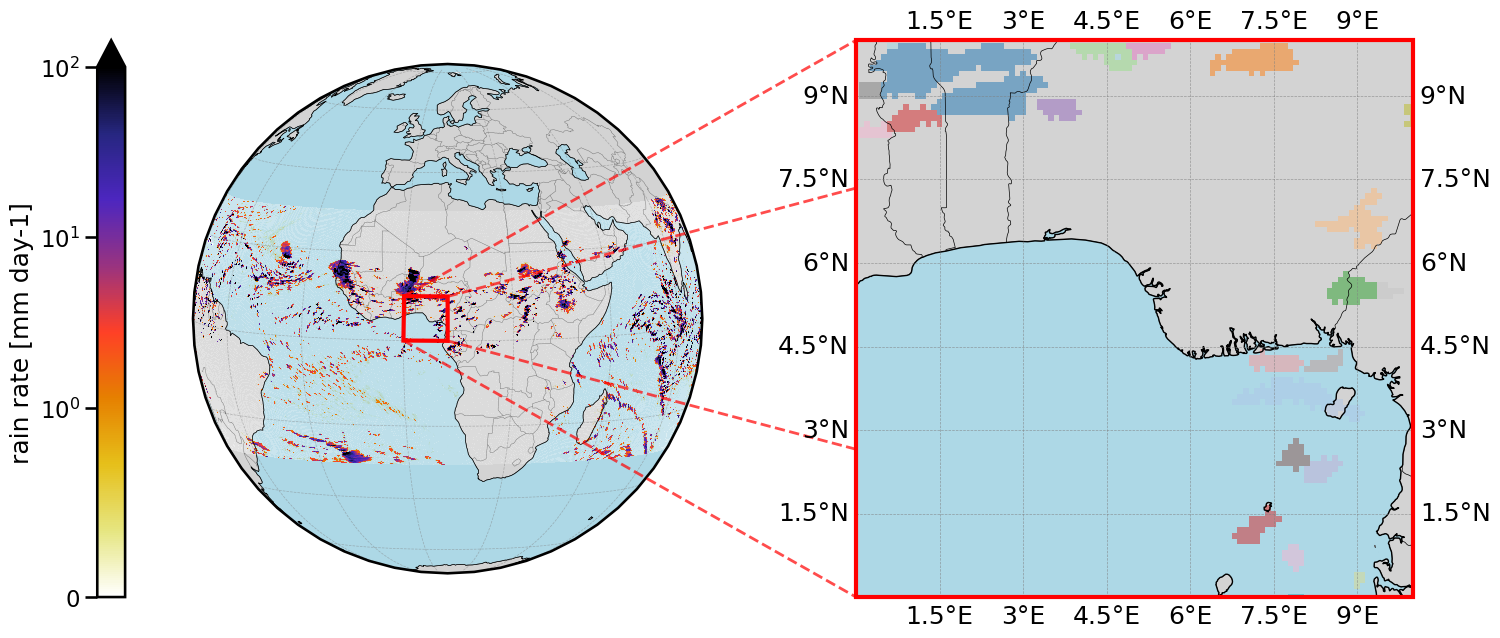

In [26]:
sns.set_context('talk')

unit = 'mm d${}^{-1}$'

# Create figure with two subplots
fig = plt.figure(figsize=(16, 7))

# Define cutout region (coast of Africa - around Gulf of Guinea)
cutout_lon = [0, 10]  # 10 degrees longitude
cutout_lat = [0, 10]  # 10 degrees latitude

# Left plot: Satellite view
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Orthographic(central_longitude=10, central_latitude=5))
ax1.set_global()

# Add features
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax1.gridlines(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

LNr = plt.matplotlib.colors.SymLogNorm(linthresh = 1, vmax= 100)

v.plot( ax = ax1,         
       transform=ccrs.PlateCarree(),  
        norm = LNr,
       alpha = 0.2,
       add_colorbar = False,
        cmap='CMRmap_r')

v.where(v>1).plot( ax = ax1,         
       transform=ccrs.PlateCarree(),  
        norm = LNr,
        cbar_kwargs={'location':'left'},
        cmap='CMRmap_r')


# Draw the cutout rectangle
rect = Rectangle((cutout_lon[0], cutout_lat[0]), 
                 cutout_lon[1] - cutout_lon[0], 
                 cutout_lat[1] - cutout_lat[0],
                 linewidth=3, edgecolor='red', facecolor='none',
                 transform=ccrs.PlateCarree(), zorder=10)
ax1.add_patch(rect)

# Right plot: Zoomed cutout
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree(), zorder=3)
ax2.set_extent([cutout_lon[0], cutout_lon[1], cutout_lat[0], cutout_lat[1]], 
               crs=ccrs.PlateCarree())

# Add features to cutout
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax2.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax2.add_feature(cfeature.COASTLINE, linewidth=1)
ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
ax2.gridlines(draw_labels=True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

LN = plt.matplotlib.colors.LogNorm(vmin = 100, vmax= 500)
vc = v.sel(lon = slice(*cutout_lon), lat = slice(*cutout_lat))


l = label.isel(time=0).sel(lon = slice(*cutout_lon), lat = slice(*cutout_lat))
l[:] = relabel_array( l.data )
l.where( l>0).plot(ax = ax2, 
                   transform=ccrs.PlateCarree(), 
                   cmap="tab20", 
                   alpha = 0.5,
                   add_colorbar = False )


# Add red border to match the cutout
for spine in ax2.spines.values():
    spine.set_edgecolor('red')
    spine.set_linewidth(3)

plt.tight_layout()

# Get subplot positions after tight_layout
pos1 = ax1.get_position()
pos2 = ax2.get_position()

# Define the corners in geographic coordinates (lon, lat)
corners_geo = [
    (cutout_lon[0], cutout_lat[1]),  # Top-left
    (cutout_lon[1], cutout_lat[1]),  # Top-right
    (cutout_lon[1], cutout_lat[0]),  # Bottom-right
    (cutout_lon[0], cutout_lat[0]),  # Bottom-left
]

# Transform corners from geographic to ax1 axes coordinates
corners_ax1_axes = []
for lon, lat in corners_geo:
    try:
        # Transform to orthographic projection coordinates
        proj_coords = ax1.projection.transform_point(lon, lat, ccrs.PlateCarree())
        # Transform to axes coordinates
        axes_coords = ax1.transData.transform(proj_coords)
        # Normalize to axes fraction
        inv_coords = ax1.transAxes.inverted().transform(axes_coords)
        corners_ax1_axes.append(inv_coords)
    except:
        corners_ax1_axes.append(None)

# Corners of ax2 in axes coordinates
corners_ax2_axes = [
    (0, 1),  # Top-left
    (1, 1),  # Top-right
    (1, 0),  # Bottom-right
    (0, 0),  # Bottom-left
]

# Draw connecting lines for all four corners
# All corners of the inset should be connected
visible_indices = [0, 1, 2, 3]  # All four corners

for idx in visible_indices:
    corner1_ax = corners_ax1_axes[idx]
    corner2_ax = corners_ax2_axes[idx]
    
    if corner1_ax is not None:
        # Convert to figure coordinates
        x1_fig = pos1.x0 + corner1_ax[0] * pos1.width
        y1_fig = pos1.y0 + corner1_ax[1] * pos1.height
        
        x2_fig = pos2.x0 + corner2_ax[0] * pos2.width
        y2_fig = pos2.y0 + corner2_ax[1] * pos2.height
        
        # Draw line in figure coordinates

        line = plt.Line2D([x1_fig, x2_fig], [y1_fig, y2_fig], 
                         transform=fig.transFigure,
                         color='red', linewidth=2, linestyle='--', 
                         alpha=0.7, zorder=1)
        
        fig.add_artist(line)

ax1.set_title('')
ax2.set_title('')


plt.show()